Description

My goal is to compare word frequencies between two works of a single author. Then compare word frequencies between works of two authors. Then determine are there some words preferred by one author but used less frequently by another author.

For the same author I chose Pride and Prejudice (1342) and Sense and Sensibility (161) by Jane Austen, and then for the different author comparison I chose Adventures of Huckleberry Finn (76) by Mark Twain and Pride and Prejudice (1342) by Jane Austen

To do this I'm going to turn each book into words and count them then divide by the total so different word counts wont skew the data. Then I will look at the most common words minus proper nouns and common stop words.

In [19]:
import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

titles = ['mr', 'mrs', 'miss', 'sir', 'lady', 'colonel', 'aunt', 'uncle', 'chapter', 'illustration']
pride_names = ['elizabeth', 'darcy', 'bennet', 'bingley', 'jane', 'wickham', 'collins', 'lydia',
               'catherine', 'lizzy', 'charlotte', 'gardiner', 'kitty', 'georgiana', 'lucas',
               'longbourn', 'netherfield', 'pemberley', 'meryton', 'rosings', 'hertfordshire', 'london']

f = open('data/pg1342.txt', 'r', encoding='utf-8', errors='replace')
text = f.read()
f.close()

start = text.find('*** START OF')
end   = text.find('*** END OF')
text  = text[start:end]

words = re.findall(r"[a-z]+", text.lower())
print('total words:', len(words))

filtered = []
for w in words:
    if w in stop_words:
        continue
    if w in titles:
        continue
    if w in pride_names:
        continue
    filtered.append(w)
words = filtered
print('words after removing stop words and names:', len(words))

pride = Counter(words)
for word, n in pride.most_common(100):
    print(word, n)


total words: 128574
words after removing stop words and names: 52270
could 531
would 485
said 406
much 337
must 315
one 295
know 244
though 238
well 230
never 230
think 222
soon 217
sister 217
good 209
might 206
may 206
time 201
little 192
nothing 187
every 185
without 177
make 171
dear 163
shall 163
first 160
say 160
man 158
room 153
family 153
see 153
great 148
day 148
two 145
mother 137
however 136
ever 136
father 135
young 133
made 132
give 127
us 127
always 126
hope 125
many 121
away 121
long 119
last 119
letter 118
way 115
friend 115
cannot 114
thought 112
enough 111
house 110
go 107
felt 106
sure 106
replied 103
love 102
saw 102
indeed 100
quite 98
better 98
wish 98
come 98
manner 97
till 96
even 95
pleasure 94
came 94
done 93
oh 93
feelings 92
often 92
really 91
cried 91
believe 90
perhaps 89
like 89
subject 87
heard 87
daughter 84
take 83
ladies 83
happy 83
anything 81
less 81
whole 80
seen 79
place 79
ill 79
brother 79
yet 78
morning 78
certainly 77
still 77
let 77
sisters 77

In [20]:
sense_names = ["elinor", "marianne", "edward", "dashwood", "jennings", "willoughby", "lucy", "john", "brandon", "ferrars", "middleton", "margaret", "fanny", "palmer", "robert", "steele", "norland", "barton", "cleveland", "delaford", "london"]

f = open('data/pg161.txt', 'r', encoding='utf-8', errors='replace')
text = f.read()
f.close()

start = text.find('*** START OF')
end   = text.find('*** END OF')
text  = text[start:end]

words = re.findall(r"[a-z]+", text.lower())
print('Sense and Sensibility total words:', len(words))

filtered = []
for w in words:
    if w in stop_words:
        continue
    if w in titles:
        continue
    if w in sense_names:
        continue
    filtered.append(w)
words = filtered
print('words after removing stop words and names:', len(words))

sense = Counter(words)
for word, n in sense.most_common(20):
    print(word, n)


Sense and Sensibility total words: 120878
words after removing stop words and names: 49242
could 578
would 515
said 397
every 376
one 331
much 290
must 283
sister 282
mother 259
well 240
time 239
know 232
though 216
might 215
think 210
nothing 189
never 189
thing 184
soon 181
good 178


In [21]:
huck_names = ["huck", "jim", "tom", "huckleberry", "finn", "sawyer", "sally", "polly", "mary", "jane", "watson", "douglas", "buck", "silas", "phelps", "harvey", "william", "peter", "wilks", "grangerford", "shepherdson", "sherburn", "boggs", "pap", "duke", "king", "jackson", "cairo", "ohio", "illinois", "missouri", "orleans", "england", "petersburg", "nigger", "niggers"]

f = open('data/pg76.txt', 'r', encoding='utf-8', errors='replace')
text = f.read()
f.close()

start = text.find('*** START OF')
end   = text.find('*** END OF')
text  = text[start:end]

words = re.findall(r"[a-z]+", text.lower())
print('Huckleberry Finn total words:', len(words))

filtered = []
for w in words:
    if w in stop_words:
        continue
    if w in titles:
        continue
    if w in huck_names:
        continue
    filtered.append(w)
words = filtered
print('words after removing stop words and names:', len(words))

huck = Counter(words)
for word, n in huck.most_common(20):
    print(word, n)


Huckleberry Finn total words: 117787
words after removing stop words and names: 48642
says 638
got 624
said 492
see 477
well 417
would 407
come 399
one 395
get 334
time 325
could 304
right 304
warn 297
went 295
good 290
way 279
go 276
like 274
old 266
around 264


Pride and Prejudice        Sense and Sensibility
could          531          could          578
would          485          would          515
said           406          said           397
much           337          every          376
must           315          one            331
one            295          much           290
know           244          must           283
though         238          sister         282
well           230          mother         259
never          230          well           240
think          222          time           239
soon           217          know           232
sister         217          though         216
good           209          might          215
might          206          think          210
may            206          nothing        189
time           201          never          189
little         192          thing          184
nothing        187          soon           181
every          185          good           178


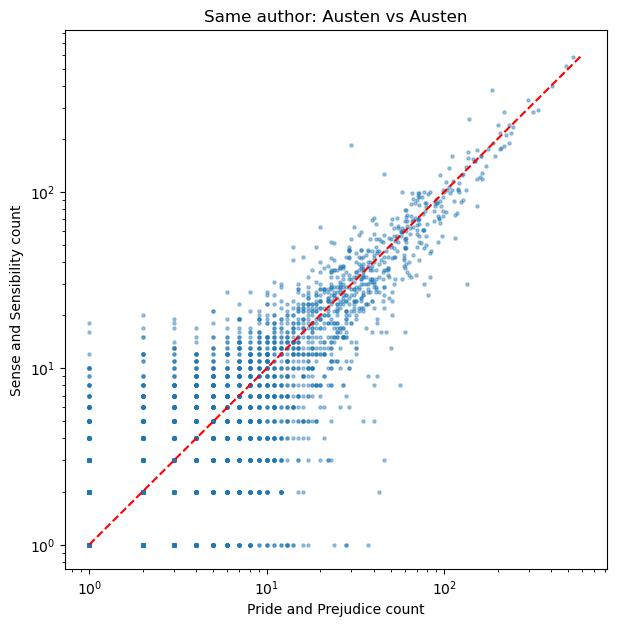

In [22]:
import matplotlib.pyplot as plt

print('Pride and Prejudice        Sense and Sensibility')
for (w1, n1), (w2, n2) in zip(pride.most_common(20), sense.most_common(20)):
    print(f'{w1:12} {n1:5}          {w2:12} {n2:5}')

x = []
y = []
for word in pride:
    if word in sense:
        x.append(pride[word])
        y.append(sense[word])

plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=5, alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.plot([1, 600], [1, 600], 'r--')
plt.xlabel('Pride and Prejudice count')
plt.ylabel('Sense and Sensibility count')
plt.title('Same author: Austen vs Austen')
plt.show()


Pride and Prejudice        Huckleberry Finn
could          531          says           638
would          485          got            624
said           406          said           492
much           337          see            477
must           315          well           417
one            295          would          407
know           244          come           399
though         238          one            395
well           230          get            334
never          230          time           325
think          222          could          304
soon           217          right          304
sister         217          warn           297
good           209          went           295
might          206          good           290
may            206          way            279
time           201          go             276
little         192          like           274
nothing        187          old            266
every          185          around         264


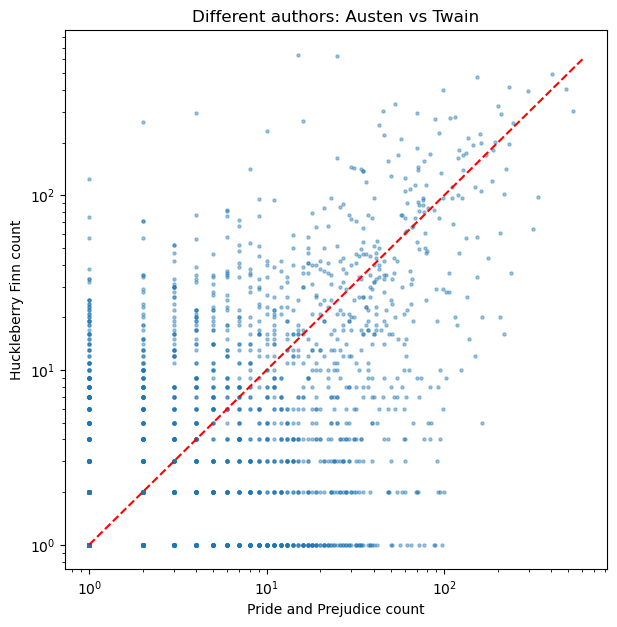

In [23]:
print('Pride and Prejudice        Huckleberry Finn')
for (w1, n1), (w2, n2) in zip(pride.most_common(20), huck.most_common(20)):
    print(f'{w1:12} {n1:5}          {w2:12} {n2:5}')

x = []
y = []
for word in pride:
    if word in huck:
        x.append(pride[word])
        y.append(huck[word])

plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=5, alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.plot([1, 600], [1, 600], 'r--')
plt.xlabel('Pride and Prejudice count')
plt.ylabel('Huckleberry Finn count')
plt.title('Different authors: Austen vs Twain')
plt.show()


In [24]:
austen_total = sum(pride.values()) + sum(sense.values())
twain_total = sum(huck.values())

ratios = {}
for word in set(pride) | set(sense) | set(huck):
    austen_count = pride[word] + sense[word]
    twain_count = huck[word]
    if austen_count + twain_count < 20:
        continue
    austen_rate = (austen_count + 1) / austen_total * 10000
    twain_rate = (twain_count + 1) / twain_total * 10000
    ratios[word] = austen_rate / twain_rate

ranked = sorted(ratios.items(), key=lambda item: item[1])

print('Words Twain prefers (Austen rate / Twain rate is small)')
for word, r in ranked[:20]:
    print(f'{word:12} austen={pride[word] + sense[word]:4}  twain={huck[word]:4}  ratio={r:.3f}')

print()
print('Words Austen prefers (Austen rate / Twain rate is large)')
for word, r in ranked[-20:][::-1]:
    print(f'{word:12} austen={pride[word] + sense[word]:4}  twain={huck[word]:4}  ratio={r:.1f}')


Words Twain prefers (Austen rate / Twain rate is small)
en           austen=   0  twain= 236  ratio=0.002
n            austen=   0  twain= 128  ratio=0.004
raft         austen=   0  twain= 118  ratio=0.004
big          austen=   0  twain=  95  ratio=0.005
knowed       austen=   0  twain=  94  ratio=0.005
dat          austen=   0  twain=  91  ratio=0.005
dey          austen=   0  twain=  82  ratio=0.006
hain         austen=   0  twain=  74  ratio=0.006
maybe        austen=   0  twain=  69  ratio=0.007
canoe        austen=   0  twain=  65  ratio=0.007
reckon       austen=   1  twain= 124  ratio=0.008
dollars      austen=   0  twain=  60  ratio=0.008
warn         austen=   4  twain= 297  ratio=0.008
git          austen=   0  twain=  51  ratio=0.009
anyway       austen=   0  twain=  48  ratio=0.010
er           austen=   0  twain=  48  ratio=0.010
gwyne        austen=   0  twain=  46  ratio=0.010
boat         austen=   0  twain=  45  ratio=0.010
island       austen=   0  twain=  43  ratio=

What is the question? 

Can word frequencies tell authors apart, and what words give each one away.

What was the approach? 

Three Gutenberg novels, split into words, stop words and names removed, top-20 lists and scatter plots for the Austen pair and the Austen-Twain pair, then a per-10,000-word ratio to rank preferred words.

What problems did I encounter? 

Character names dominating the counts. Dialect contractions like "warn't" and "hain't" losing their apostrophes and leaving fragments. Only one Twain book, so his "preferred" words may be Huck Finn's subject matter rather than his style.

What results did I get? 

The Austen pair shares 17 of its top 20 words, the Austen-Twain pair shares 7. Twain's signature is action verbs and dialect: says, got, reckon, knowed, raft, canoe. Austen's is formal connectives and social words: however, therefore, replied, affection, acquaintance, marriage.

What new ideas did this generate? 

Adding Tom Sawyer to check Twain's consistency. Fixing the regex to keep apostrophes. Trying the binomial extra credit on "would."